# Laser Guide Stars
Jandrie Rodriguez
April 2026

This notebook works witht the Laser enviorment but also needs the python package ambiance 1.3.1.
https://pypi.org/project/ambiance/

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ambiance import Atmosphere
from ipywidgets import FloatSlider, interact

## Laser Guide Star Background

**Laser Guide Stars (LGS)** were introduced in the early 1980s as a solution to fix the atmospheric-imposed perturbations to astronomical objects' wavefronts at ground-based observatories.
Ground-based observatories for astronomical objects such as stars use adaptive optics to resolve a star's true wavefront after distortion imposed by Earth's atmosphere.
Observatories implement control loops with adaptive optics and a reference point such as a star to correct the wavefront.

**Natural Guide Stars (NGS)** are bright stars located near the astronomical object of interest; sadly, not all astronomical objects have an NGS near them.
Artificial Stars, or Laser Guide Stars, are used when no bright NGS are available. The most common LGS types are Rayleigh LGS and Sodium LGS, which use scattering to form bright reference points in the sky.

## Looking at the stars 

The light from an astronomical object such as a star has a plane wavefront until it enters our atmosphere. 
The wind and temperature differences cause atmospheric turbulence, distorting the wavefront. The turbulence changes the index of refraction throughout the light's path. This is why we see the stars twinkle. 
The atmospheric turbulence has been modeled using LGS and NGS observations and as technology advances, more tools become available.
At present, researchers are using deep learning to simulate the turbulence accurately (Shohani, 2023)[1].

<div align="center">

![No Adaptive Optics](<distorted wave.png>)

Figure 1: Diagram of imaging an astronomical object without adaptive optics from Burn (2023)[2].

</div>

Adaptive optics are used to correct the twinkle. The distorted wavefront hits a Deformable Mirror (DM) and sometimes a Tip-Tilt Mirror, then travels along to a wavefront sensor and a science camera. 
The wavefront sensor drives the Deformable Mirror to form into the needed shape to turn the wavefront to planar and adjust the tip/tilt mirror to fix the jitter "twinkle" of the image.
To accurately correct the image distortion, a reference point is used because as a known source it can be back calculated to identify the atmospheric perturbations imposed on it (Rao et al., 2024)[3].


<div align="center">

<img src="adaptive optics.webp" alt="Adaptive Optics Control" style="width: 50%;">

Figure 2: Simplified schematic imaging a astronomical object with adaptive optics made by Rao et al. (2024)[3].



![Neptun imaging with and with out AO](Neptune-imaged-with-the-Keck-10-m-telescope-without-left-and-with-right-AO-The.png)


Figure 3: Neptune, imaged with the Keck 10m telescope, without (left) and with (right) Adaptive Optics from (Wizinowich ,2014) [2].
</div>

## Types of Laser Guide Stars

Sodium LGS  was the first propsed LGs and is more commonly used at large telescopes. The Sodium LGS use scattering a the sodium layer in out atmospher to produce a bright refernce point around 90km abouve sea level.
Rayliegh LGS was proposed after Sodium LGS as a cost effective alternitive with a referene point around 10-20km.

<div align="center">

<img src="bothlgs.webp" alt="R and L lSG refrence point" style="width: 30%;">

Figure 4: Depiction of the differnt altitude refernce points between a Rayliegh LSG and  Sodium LSG made by Rao et al.(2024).

</div>

The position of the each Laser Guid Star's refernce point is based on the different types of scattering each LSG uses. 

## Scattering

The Lidar Equation explains the energy detected at a reciver from scattering process when a light propogates through a medium by expected number of photons $N(z)$ detected in range interval $\Delta z$. For this equation $\Delta z < z$ so that the transmition of atmosphere between telescope and beacon $T_A$ and the effective backscatter cross-section $\sigma_B$ is constant over $\Delta_A$.


$$
N(z) = \underbrace{\left(\frac{E\lambda}{hc}\right)}_{\text{
    n transmitted photons}} \underbrace{(\sigma_B n(z) \Delta z)}_{\text{P(a photon is scattered)}} \underbrace{\left(\frac{A_R}{4\pi z^2}\right)}_{\text{P(a scattered  photon is collected)}} \underbrace{(T_o T_A^2 \eta)}_{\text{P(a collected photon detected)}} + \underbrace{N_B}_{\text{background photons}}
$$

where,

- $E$ = laser pulse energy, J
- $\lambda$ = optical wavelength, m
- $h$ = Planck's constant, $6.626 \times 10^{-34}$ Js
- $c$ = velocity of light, $3 \times 10^8$ m s$^{-1}$
- $\sigma_B$ = effective backscatter cross-section, m$^2$
- $n(z)$ = number density of scatterers at range z, m$^{-3}$
- $\Delta z$ = receiver range gate length, m
- $A_R$ = area of receiving aperture, m$^2$
- $z$ = range at center of range gate, m
- $T_o$ = transmission of optical components in transmit and receive paths -- Component Loss
- $T_A$ = one-way transmission of atmosphere between telescope and beacon -- Atmospheric Condition
- $\eta$ = quantum efficiency of photon detector at wavelength $\lambda$
- $N_B$ = number of background and noise photoelectrons.

## Rayleigh Laser Guide Star - Rayleigh Scattering and Backscatter Cross-section 

**Rayleigh Scattering** is the radiation scattered from atoms/molecules with no change in frequency classified as elastic scattering (Hardy, 1998)[5]. 
When the electric field from light comes in contact with a molecule in the air, such as Nitrogen $N_2$ or Oxegyn $O_2$, the molecule induces a fluctuating dipole moment which emits radiation.
We know that shorter wavelengths like <font color="blue"> 400 nm </font> are more effective at scattering the radiation than higher wavelengths. 
For adaptive optics, Rayleigh scattering is of interest within  the lower altidude atmosphere.

Rayleigh backscattering cross section is defined as, 
$$
\sigma_B^R = \frac{\pi^2 (n^2 - 1)^2}{N^2 \lambda^4},
$$
where N is number of photons, n is the refraction index, and lambda is of course the wavelength.
According to Hardy (1998)[5], with the mixtures of gases in the atmospher below 100km $\sigma_B^R$ is equvalent to,  
$$
\sigma_B^R(\lambda) = 5.45 \left[\frac{550}{\lambda \text{(nm)}}\right]^4 \times 10^{-32} \text{ m}^2 \text{ sr}^{-1},
$$
Note the unit sr is steradian the SI unit of solid angle.

Connecting to the Lidar equation the probability of a photon scatterted over $\Delta z$,
$$
\sigma_B^R \, n_R(z) = 3.6 \times 10^{-31} \frac{P(z)}{T(z)} \lambda^{-4.0117},
$$
where P(z) is the atmospheric pressure at range z andT(z) is the atmospheric temprature K at range z. 

**Rayling Laser Star Guide use this scattering and can produce a LGS around 10-20 km above the ground** [3,4]. Additionally becuase the scattering prefers lower wavelength any laser in the ultra violet specrum can be used.

*Pulse laser* are used for this set up to use range gating at the detectors. **Range Gating** allows the detector to synchronize with the lasers back propagation to avoide unwanted scattering.
 



interactive(children=(FloatSlider(value=532.0, description='$\\lambda_L$ (nm):', max=1064.0, min=250.0, readou…

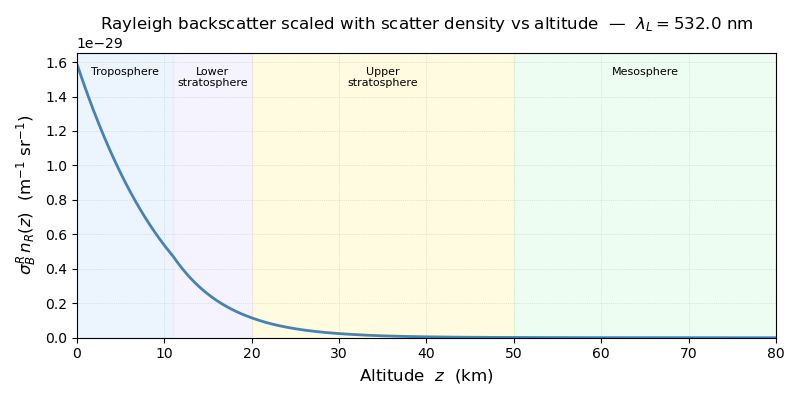

In [2]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ambiance import Atmosphere
from ipywidgets import FloatSlider, interact

# Altitude
z_km = np.linspace(0.1, 80, 2000)
z_m = z_km * 1000 #km

# Atmosphere stuff
atm = Atmosphere(z_m)
P = atm.pressure / 100    # Pa → mPa equation uses mPa
T = atm.temperature       # K

# Initial wavelength
lambda_nm_0 = 532.0
sigma_n_0  = 3.6e-31 * (P / T) * (lambda_nm_0 ** -4.0117) # Hardy eq.
y_max = sigma_n_0.max() * 1.05

fig, ax = plt.subplots(figsize=(8, 4))

# Atmosphere sections
layers = [
    (0,  11,  '#dbeafe', 'Troposphere'),
    (11, 20,  '#ede9fe', 'Lower\nstratosphere'),
    (20, 50,  '#fef9c3', 'Upper\nstratosphere'),
    (50, 80,  '#dcfce7', 'Mesosphere'),
]
for z0, z1, col, label in layers:
    ax.axvspan(z0, z1, color=col, alpha=0.5)
    ax.text((z0 + z1) / 2, 0.95, label,
            fontsize=8, va='top', ha='center',
            transform=ax.get_xaxis_transform())

# Set to object for slider
curve, = ax.plot(z_km, sigma_n_0, color='steelblue', linewidth=2)

ax.set_xlabel('Altitude  $z$  (km)', fontsize=12)
ax.set_ylabel(
    r'$\sigma_B^R\,n_R(z)$  (m$^{-1}$ sr$^{-1}$)',
    fontsize=12)
title = ax.set_title(
    r'Rayleigh backscatter scaled with scatter density vs altitude'
    f'  —  $\\lambda_L = {lambda_nm_0:.1f}$ nm')
ax.set_xlim(0, 80)
ax.set_ylim(0, y_max)
ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.6)
ax.tick_params(labelsize=10)
plt.tight_layout()

# Update
def update(lambda_nm=lambda_nm_0):
    lambda_um  = lambda_nm / 1000
    sigma_n   = 3.6e-31 * (P / T) * (lambda_um ** -4.0117)

    curve.set_ydata(sigma_n)
    ax.set_ylim(0, sigma_n.max() * 1.05)
    title.set_text(
        r'Rayleigh backscatter scaled with scatter density vs altitude'
        f'  —  $\\lambda_L = {lambda_nm:.1f}$ nm')
    fig.canvas.draw_idle()


# Slider
lambda_slider = FloatSlider(
    value=lambda_nm_0,
    min=250,
    max=1064,
    step=1.0,
    description=r'$\lambda_L$ (nm):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

interact(update, lambda_nm=lambda_slider)
plt.show()

## Sodium Laser Guide Star- Resonance Scattering and Backscatter Cross-section 

Sodium Laser Guide stars use **Resonance Scattering** to create a bright artifical reference point. 
Resonance scatterig for our case occurs when an incident photon of a certain energy collides  with an atom of matched ground to excited state transition energy and emits a photon with that energy.  
Sodium Na has the transition from the ground state to the first excited (a doublet) of D1 at 589.6nm and D2 of 589nm. In practice **Sodium Laser Guide Star uses resonance scatering with the transtion between ground state to $D_2$ with a preciesly tuned 589 nm wavelegth laser**. Most large telescope observatories use 10-50 W lasers. 
The resonance scattering is cuased by **optical pumping** and we can undersant the behavior using rate equations!
Sodiums hyperfine structure produces saturation limits. 

The sodium Na layer in our atmospher is around 90 km above sea level and is 10 km thick. This layer has varying atmoshperic gass density profile throught the seasons and varies between $1.7 x10^{-20}$ to $2.9 x10^{-19} m^{-3}$ (Moussaoui, 2008)[6].
The fluctation of the density profile and different tempratures in the sodium layer complicates the bakscatter derivation.

To get a conceptual idea of how the Sodium's backscatter cross-section is deived, I will go though the **Doppler-Broading** and **Saturation**.

## Doppler-Broading

Since the sodium atoms are not stationary and are spread out throughout the sodium layer with also fluctuating temprarues there is a varaition of the velocities of every atom.
Therfore, in the lab frame as the photons are set to the resonance frequency Na atoms can be <font color="blue"> blue shifted </font> and others <font color="red"> redshifted shifted </font>. 



<div align="center">

![Dopple broaden sodium ](<Doppler_b.png>)

Figure 4: Aborbtion cross section of sodium with doppler broaden. With out dopple broadening absoption peaks are 1772 MHz apart. Larger broadening is shown as tempretur increases [4].

</div>

Then in the sodium layer there are atoms that are emmiting a photon at a small offest from the intended resoance frequency of $5.09 x 10^{14} Hz$.
The total backscatter cross section with be both photons is described with the angular resonance frequency $\omega =\frac{2 \pi c}{lamda} = $3.20 x10^{15}$ rad/s and with some angular offset frequecny $\omega_d$ rad/s.

According to Hardy, Doppler-broadened sodium absorption cross-section evaluated at the difference of the angular frequency of the photon and the central resonance frequency. $(\omega - \omega_d)$ is $\sigma(\omega - \omega_d)$ .

The Effective absorption cross-section for atoms at Doppler shift $\omega_d$ is defined as,

$$ \sigma_eff(\omega_d) = \int_{-\infty}^{\infty}  \sigma(\omega - \omega_d)\, g(\omega)\, d\omega.$$

where, 
$g(\omega)$ is the velocity distribution profile.

## Saturation 

First, let's simplify the behavior of the resonance scatter to a two level system. 

<div align="center">

![Simplified version of sodium](2_level_system.png)

Figure 4: Two level system depicting back scattering from Hardy (1998) [5].

</div>

In this system we have the number of atoms in the excited state $N_2$, in the ground state $N_1$, and $n(t)$ photons per unit volume.
The spontaneous decay rate of the sodium D2 line is $\gamma_{21} = 1/\tau$, with $\tau = 16.24\ \mathrm{ns}$.
Additionally, $K$ is the atom-photon coupling rate constant. 

In our simplified version we assume total number of atoms is conserved,  $N = N_1 + N_2$, so,
$$\frac{dN_1}{dt} = -\frac{dN_2}{dt} $$

So as we have done before in class, the two level system has the following rate equations.


*Spontaneous Emission*:$\frac{dN_2}{dt} = -\gamma_{21}\, N_2(t) $.

*Absorption*: $\frac{dN_2}{dt} = K n(t) N_1(t)$.

A larger $K$ indicates stronger coupling between the photon field and the atomic transition. For sodium, $K$ is large because the resonance cross-section $\sigma_{\mathrm{Na}} \sim 10^{-13}\ \mathrm{m}^2$ is many orders of magnitude larger than the Rayleigh backscatter cross-section [5].

*Stimulated Emission*: $ \frac{dN_2}{dt} = -K n(t) N_2(t)$


Now the *Total Rate Equation*,

$$\frac{dN_2}{dt} = K n(t),\bigl(N_1(t) - N_2(t)\bigr) - \gamma_{21}N_2(t)$$


Then *Steady State Solution*,
for a continuous wave (cw) laser, we set $dN_2/dt = 0$.
$$0 = K\, n\,\bigl(N_1 - N_2\bigr) - \gamma_{21}\, N_2.$$
Substituting $N_1 = N - N_2$ and solving for $N_2$.
$$N_2 = \frac{K n}{\gamma_{21} + 2K n} N$$

Based on how $N_2$ behaves we see a two ** Limit**.

Two key ranges are:

**Linear** 
($K n \ll \gamma_{21}$):return flux grows linearly with laser power,
$$ N_2 \approx \frac{K\,n}{\gamma_{21}} N.$$


**Saturation** 
($K n \gg \gamma$: $N_2 \propto n$): no more than half the atoms can be in the excited state simultaneously in a two-level system 
$$ N_2 \longrightarrow \frac{N}{2}.$$


We can related $K\cdot n$ to $\sigma_eff \cdot \Phi$ by the properites of $K$ and $n$.

Again, $K$ is the atom-photon coupling constant and can also be describes absorbtion cross-section times the speed of light $K =\sigma \cdot c $[m^3/s].
The number phonots per unit volume $n$ is the energy density $u$ by the the energy of a single phonton $h \nu$. Assuming in vaccume, intensity is the product of energy density and the speed of light.

Now it is clear to express, 
$$\mathbf{K\cdot n = \sigma _{eff} \cdot \frac{I}{h \nu}} = \mathbf{\sigma_{eff} \cdot \Phi}$$

So the steady state solution with saturation included is ,
$$N_2 = \frac{\sigma_{eff} \cdot \Phi}{\gamma_{21} + 2 \sigma_{eff} \cdot \Phi} N$$

Connecting this to the full backscatter cross-section formulas by integrating $N_2$ over the beam cross-section to get the total number of excited atoms!


### Back to the Backscatter Cross-section

Hardy defines a Gaussian Beam and rectangular laser pulse to have a backscattering cross- section,

$$\sigma_S = \int_{-\infty}^{\infty} \frac{\tau_S \sigma_T  n(\omega_d)}{2\tau_n n_0} \ln \left[ \frac{2\tau_n \sigma_\text{eff}(\omega_d)} {\tau_S  \sigma_T} + 1 \right] d\omega_d,$$
where,
$\tau_S$ = saturation time s. A measure of stimulated emission.
$\sigma_T$  = total effective absorption cross-section of sodium atoms in the *unsaturated* limit m$^2$
$\tau_n$ = natural life time of decay
$n_0$ = total integrated density of the Na atom. 
To note the peak flux for a guasian beam with a radius $\rho$ is $\Phi(\rho) =\Phi_0 e^{-\rho^2/a^2}$

My examples are for a conceptual understanding of aspect needed to take into consideration hwen looking at resonance scattering in the Sodium layer.

interactive(children=(FloatSlider(value=20.0, description='$P$ (W):', max=200.0, min=1.0, readout_format='.0f'…

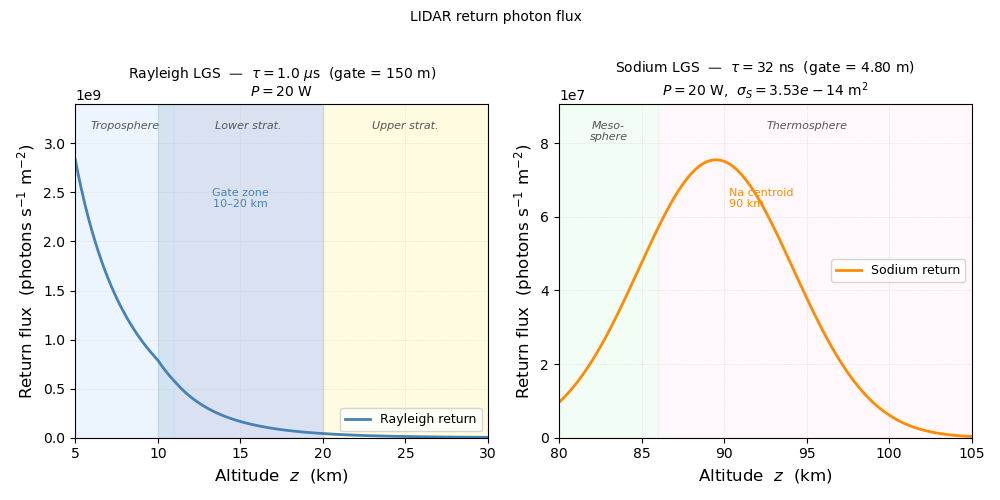

In [3]:
# Certain parameters where used to follow  Holzlöhner (2010) [8].
# used the power version of the LIDAR equation first term P_laser/Ephonton since pulse laser.rate of flow of discreate particles throygh a unit suface area 
# Had missing terms but think still get point across. 
#Missing air mass X 


# Constants
c = 3e8 #speed of light
h_planck = 6.626e-34
k_B  = 1.381e-23
tau_n  = 16.24e-9 # time from rate decay/exsitation 
gamma_21  = 1.0 / tau_n #function
sigma_peak = 1.0e-13 # sodium D2 peak
nu_Na = c / 589.159e-9 # frequency
E_photon = h_planck * nu_Na #energy of photon

#parameters
D_tel = 8.0 #tel diameter m
A_r = np.pi * (D_tel / 2)**2 # cross section area
w_lt = 0.1   # waist m
beam_area = np.pi * w_lt**2
eta = 0.5 # how many photons actually arrive
T_a  = 0.84 # transmition from paper
lambda_um = 589.159 

# Different Altitdueds-- did not work when on the same plot
z_R_km  = np.linspace(5, 30, 1000)
z_R_m   = z_R_km * 1000 # to km
z_Na_km = np.linspace(80, 105, 1000)
z_Na_m  = z_Na_km * 1000 # to km

# Rayleigh atmosphere
atm_R     = Atmosphere(z_R_m)
P_Pa_R    = atm_R.pressure
T_K_R     = atm_R.temperature
n_R       = P_Pa_R / (k_B * T_K_R) #molecule per m^3

sigma_B_R = 5.45e-32 * (550 / 589.159)**4 # rayliegh back scattering
beta_R    = sigma_B_R * n_R #proability /delta z

dz_R      = np.gradient(z_R_m) # get altitude for each step -- integration
N_col_R   = np.cumsum(n_R * dz_R) # total molecular column density
T2_R      = np.exp(-2.0 * sigma_B_R * N_col_R) # two way transmition Beer-Lamber law

# Overlap function for LIDAR no beam seen at close range to telescope
z_overlap = 10.0
O_R       = np.minimum(z_R_km / z_overlap, 1.0) # got a spike z-> 0 without it

# Sodium layer
z_Na_cen  = 90.0 #km
fwhm_Na   = 11.0 # from paper 
sig_Na_z  = fwhm_Na / (2 * np.sqrt(2 * np.log(2))) #standar deviation 
C_Na      = 4.0e13  #column density paper
n_Na_peak = C_Na / (sig_Na_z * 1000 * np.sqrt(2 * np.pi)) #
n_Na      = n_Na_peak * np.exp(-0.5 * ((z_Na_km - z_Na_cen) / sig_Na_z)**2)# guas center with std
T2_Na     = T_a**2    # two way transmition no spatial component


#Sodium saturation

def compute_sigma_S(P_laser):
    Phi   = P_laser * T_a / (E_photon * beam_area) #constant
    x     = max(2 * sigma_peak * Phi / gamma_21, 1e-10) # saturation parameter
    f_sat = np.log(x + 1) / x
    return sigma_peak * f_sat

# LIDAR with pulse time parameter

def compute_rayleigh_return(P_laser, tau_us):
    tau    = tau_us * 1e-6   # us -> s
    z_safe = np.maximum(z_R_m, 1.0) #pulse
    return (
        (P_laser / E_photon)
        * (c * tau / 2.0)
        * A_r / z_safe**2
        * eta
        * O_R
        * beta_R
        * T2_R
    )

def compute_sodium_return(P_laser, tau_ns):
    tau     = tau_ns * 1e-9       # ns -> s
    z_safe  = np.maximum(z_Na_m, 1.0) #pulse are different
    sigma_S = compute_sigma_S(P_laser) #saturation
    beta_Na = sigma_S * n_Na #probability
    return (
        (P_laser / E_photon)
        * (c * tau / 2.0)
        * A_r / z_safe**2
        * eta
        * beta_Na
        * T2_Na
    )


# Values
P_0      = 20.0
tau_R_0  = 1.0      # microseconds
tau_Na_0 = 32.0     # nanoseconds

P_r_R_0  = compute_rayleigh_return(P_0, tau_R_0)
P_r_Na_0 = compute_sodium_return(P_0, tau_Na_0)
sig_S_0  = compute_sigma_S(P_0)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(    r'LIDAR return photon flux  ', fontsize=10)

# Rayleigh 
rayleigh_layers = [
    (5,  11, '#dbeafe', 'Troposphere'),
    (11, 20, '#ede9fe', 'Lower strat.'),
    (20, 30, '#fef9c3', 'Upper strat.'),
]
for z0, z1, col, label in rayleigh_layers:
    ax1.axvspan(z0, z1, color=col, alpha=0.5)
    ax1.text((z0+z1)/2, 0.95, label,
             fontsize=8, va='top', ha='center',
             transform=ax1.get_xaxis_transform(),
             color='#555', style='italic')

ax1.axvspan(10, 20, color='steelblue', alpha=0.15)
ax1.text(15, 0.75, 'Gate zone\n10–20 km', fontsize=8, color='steelblue', ha='center', va='top', transform=ax1.get_xaxis_transform())

curve_R, = ax1.plot(z_R_km, P_r_R_0, color='steelblue', linewidth=2,  label='Rayleigh return')

ax1.set_xlabel('Altitude  $z$  (km)', fontsize=12)
ax1.set_ylabel(r'Return flux  (photons s$^{-1}$ m$^{-2}$)', fontsize=12)
title_R = ax1.set_title( f'Rayleigh LGS  —  '
    f'$\\tau = {tau_R_0:.1f}$ $\\mu$s  '
    f'(gate = {c*tau_R_0*1e-6/2:.0f} m)\n'
    f'$P = {P_0:.0f}$ W',
    fontsize=10)
ax1.set_xlim(5, 30)
ax1.set_ylim(bottom=0)
ax1.legend(fontsize=9)
ax1.grid(True, linestyle=':', linewidth=0.5, alpha=0.5)

# Sodium
ax2.axvspan(80, 86, color='#dcfce7', alpha=0.4)
ax2.axvspan(86, 105, color='#fce7f3', alpha=0.3)
ax2.text(83, 0.95, 'Meso-\nsphere',
         fontsize=8, va='top', ha='center',
         transform=ax2.get_xaxis_transform(),
         color='#555', style='italic')
ax2.text(95, 0.95, 'Thermosphere',
         fontsize=8, va='top', ha='center',
         transform=ax2.get_xaxis_transform(),
         color='#555', style='italic')
ax2.text(z_Na_cen + 0.3, 0.75,
         f'Na centroid\n{z_Na_cen:.0f} km',
         fontsize=8, color='darkorange', va='top',
         transform=ax2.get_xaxis_transform())

curve_Na, = ax2.plot(z_Na_km, P_r_Na_0,
                     color='darkorange', linewidth=2,
                     label='Sodium return')

ax2.set_xlabel('Altitude  $z$  (km)', fontsize=12)
ax2.set_ylabel(
    r'Return flux  (photons s$^{-1}$ m$^{-2}$)',
    fontsize=12)
title_Na = ax2.set_title(
    f'Sodium LGS  —  '
    f'$\\tau = {tau_Na_0:.0f}$ ns  '
    f'(gate = {c*tau_Na_0*1e-9/2:.2f} m)\n'
    f'$P = {P_0:.0f}$ W,  '
    f'$\\sigma_S = {sig_S_0:.2e}$ m$^2$',
    fontsize=10)
ax2.set_xlim(80, 105)
ax2.set_ylim(bottom=0)
ax2.legend(fontsize=9)
ax2.grid(True, linestyle=':', linewidth=0.5, alpha=0.5)

plt.tight_layout()


# Update power and pulse time
def update(P_laser=P_0, tau_R_us=tau_R_0, tau_Na_ns=tau_Na_0):

    P_r_R  = compute_rayleigh_return(P_laser, tau_R_us)
    P_r_Na = compute_sodium_return(P_laser, tau_Na_ns)
    sig_S  = compute_sigma_S(P_laser)

    gate_R  = c * tau_R_us  * 1e-6 / 2.0
    gate_Na = c * tau_Na_ns * 1e-9 / 2.0

    curve_R.set_ydata(P_r_R)
    ax1.set_ylim(0, max(P_r_R.max(), 1e-30) * 1.2)
    title_R.set_text(
        f'Rayleigh LGS  —  '
        f'$\\tau = {tau_R_us:.1f}$ $\\mu$s  '
        f'(gate = {gate_R:.0f} m)\n'
        f'$P = {P_laser:.0f}$ W')

    curve_Na.set_ydata(P_r_Na)
    ax2.set_ylim(0, max(P_r_Na.max(), 1e-30) * 1.2)
    title_Na.set_text(
        f'Sodium LGS  —  '
        f'$\\tau = {tau_Na_ns:.0f}$ ns  '
        f'(gate = {gate_Na:.2f} m)\n'
        f'$P = {P_laser:.0f}$ W,  '
        f'$\\sigma_S = {sig_S:.2e}$ m$^2$')

    fig.canvas.draw_idle()

# Sliders
power_slider = FloatSlider(
    value=P_0, min=1.0, max=200.0, step=1.0,
    description='$P$ (W):',
    continuous_update=True,
    readout=True, readout_format='.0f')

tau_R_slider = FloatSlider(
    value=tau_R_0, min=0.1, max=10.0, step=0.1,
    description=r'$\tau_R$ ($\mu$s):',
    continuous_update=True,
    readout=True, readout_format='.1f')

tau_Na_slider = FloatSlider(
    value=tau_Na_0, min=5.0, max=200.0, step=1.0,
    description=r'$\tau_{Na}$ (ns):',
    continuous_update=True,
    readout=True, readout_format='.0f')

interact(update,
         P_laser=power_slider,
         tau_R_us=tau_R_slider,
         tau_Na_ns=tau_Na_slider)
plt.show()

As we can see for Rayliegh LGS a longer pulse $\mu s$ results in more photon flux at the detector. For sodium when the pulse laser is increased $ns$ the flux still increases very minimal since most of the layer in the refernce point is sampled always.
Both LSG increase flux with power but the Sodium LGS starts to increase slower becuase of saturation.

## Disadvantage 

### Cone Effect -- Focal Anisoplantism 

Thinking of how a the laser from the telescope propagate outward toward it focuse (refernce point), we get a cone. The cone for both the Rayliegh and Sodium Laser guides stars limits the smapling of both techniques. The amount of turbulance recived by the LSG is therfore less than an astronomical object since, the light from the object will pass through a cylindrical column onto the telescope.[4,9]

<div align="center">
<img src="cone effect.png" alt="Cone effect" style="width: 30%;">

Figure 6: Cone effect shown with respect to the backscattrting layer and an astronomical source shown in Foy (2000)[9].
</div>

The cone effect produces a risidual error to the wave front by, 

$$ \sigma_{\phi}= (\frac{D}{d_0})^{5/6}. $$

D is the diameter of the telescope and $d_0$ is isoplanatic diameter for the LSG at a certain height. The isoplantic patch is the angle seperation between the LGS and an astronomical object where the wavefront distortion between the two is enough to have a good correction with the adaptive optics. **As opposed to NSG the Laser Guide Star can be placed at a point near the astronomical object where the error is minamal.** 
This effect is a reson why smaller observatories use Rayleigh LSG becuase the cone effect error decreases at smalller apatures. 

A way that the cone effect can be reduced is to use multiple LSG. 


## Multi- Conjugate Adaptive Optics 


A Multi Conjucaget Adaptive Optics MCAO system uses multiple laser guide stars and deformable mirrors. Using more than one LSG alwos the correction of atmospherec terbulance in three dimensions. 
With a better model of the atmospheric teurbulance these systems increase the feild of view from 10-20 times larger for high resolution imaging. 

<div style="display: flex; flex-direction: row; gap: 10px;">
    <img src="maco0.png" width="30%" />
    <img src="maco1.png" width="30%" />
    <img src="maco2.png" width="30%" />
</div>
Figure 7: Simplified diagram of how Multi-Conjuage Adaptive Optics are set up. There is a ground conjugate deformable mirror loop to correcct the atmospheric turbulance closer to the ground and altitude conjugate deformable mirrors to resovle atmospheric turbulace at high altitudes. The system can be set to be start orriented, to recunstuct atmospheric turbulance by measuring the wave front along every LSG. The system can also be set up in Layer orientation were the LSG light is combined and used to mesure the atmospheric turbulance at a certain altitude. Image form European Southern Observatory. 


Using multiple LSG has decreased the cone effect and can be shown in comparison to the **Strehl ratio**. The strehl ration mesures how close an image is to the difraction limit. If an image has an Airy pattern then it is considered a 100% strehl ratio. When the cone effect starts to be significant the strehl ratio becuomes 37% (Rigaut 2018) [11].


In 2018 a review by Francois Rigaut and Benoit Neichel showed that the  Multi- Conjugate Adaptive Optics leads to a field of view about 100 arcsecons until the strehl ratio becomes to sevier.
The field of LSG has kept improving since it's proposal. 

<div align="center">

<img src="stehl_fov.png" width="40%" />


Figure 8: Comparison of differnt Adaptive optics set ups to the strehl ratio and field of view (Rigaut 2018)[11].


## References
[1] Shohani, Jafar Bakhtiar, Morteza Hajimahmoodzadeh, and Hamidreza Fallah. "Deep Learning for Multi-Star Recognition in Optical Turbulence." Opt. Continuum, vol. 1, 2022, pp. 2347–2359.

[2] Brun, Cécile. "Wavefront Sensing and Adaptive Optics with First Light Imaging Cameras." Oxford Instruments Andor, May 2023, andor.oxinst.com/learning/view/article/wavefront-sensing-adaptive-optics-with-first-light-imaging-cameras. Accessed 20 Apr. 2026

[3] Rao, Changhui, et al. "Astronomical Adaptive Optics: A Review." PhotoniX, vol. 5, 2024, doi:10.1186/s43074-024-00118-7.

[4] Wizinowich, Peter. "Adaptive Optics in Astronomy." Contemporary Physics, vol. 56, 2015, pp. 1–19, doi:10.1080/00107514.2015.1041765.

[5] Hardy, John W. Adaptive Optics for Astronomical Telescopes. Oxford University Press, 1998.

[6] Moussaoui, N., et al. "Effect of the Geomagnetic Field on the Intensity of Sodium Laser Guide Stars." Proceedings of SPIE, vol. 7015, 2008, p. 70152W, doi:10.1117/12.803921.

[7] Huo, Xiaowei, et al. "Research Development of 589 nm Laser for Sodium Laser Guide Stars." Optics and Lasers in Engineering, vol. 134, 2020, p. 106207, doi:10.1016/j.optlaseng.2020.106207.

[8] Holzlöhner, Ronald, et al. "Optimization of CW Sodium Laser Guide Star Efficiency." Astronomy and Astrophysics, vol. 510, 2010, p. A20, doi:10.1051/0004-6361/200913108.

[9] Foy, R. "The Cone Effect." Laser Guide Star Adaptive Optics for Astronomy, edited by N. Ageorges and C. Dainty, Springer, 2000, pp. doi:10.1007/978-94-015-9624-4_6.

[10] Rigaut, François, and Benoit Neichel. "Multiconjugate Adaptive Optics for Astronomy." Annual Review of Astronomy and Astrophysics, vol. 56, 2018, pp. 277–314, doi:10.1146/annurev-astro-091916-055320.

[11] European Southern Observatory. "Adaptive Optics Modes." ESO, www.eso.org/sci/facilities/develop/ao/ao_modes.html. Accessed 20 Apr. 2026.

